# **classification faces with CNN**

In [83]:
#import libs
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

#import opencv
import cv2
import imghdr

#import Tensorflow libs
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Conv2D,MaxPooling2D,Flatten,Dropout
from tensorflow.keras.metrics import BinaryCrossentropy,Precision,Recall,BinaryAccuracy
from tensorflow.keras.models import load_model

# import joblib
import joblib
from IPython.core.pylabtools import figsize

In [44]:
cpu=tf.config.experimental.list_physical_devices('CPU')

In [45]:
# clean images
data_dir='data'
image_exts=['jpg','jpeg','png','bmp']


In [46]:
os.listdir(data_dir)

['happy', 'sad']

In [47]:
for image_class in os.listdir(data_dir):
    for image in os.listdir(os.path.join(data_dir,image_class)):
        image_path=os.path.join(data_dir,image_class,image)
        try:
            image = cv2.imread(image_path)
            tip=imghdr.what(image_path)
            if tip not in image_exts :
                print(f"image not in ext list{image_path}")
                os.remove(image_path)
        except Exception as e:
            print(f'Issue with image {image_path}')


In [48]:
# load data
data= tf.keras.utils.image_dataset_from_directory('data')

Found 305 files belonging to 2 classes.


In [49]:
data_iterator=data.as_numpy_iterator()

In [50]:
#images represented as numpy arrays
# 0 -> Happy ,1-> Sad
batch=data_iterator.next()
batch[0].shape

(32, 256, 256, 3)

In [51]:
batch[1]

array([1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0,
       0, 1, 0, 0, 1, 1, 0, 0, 1, 0], dtype=int32)

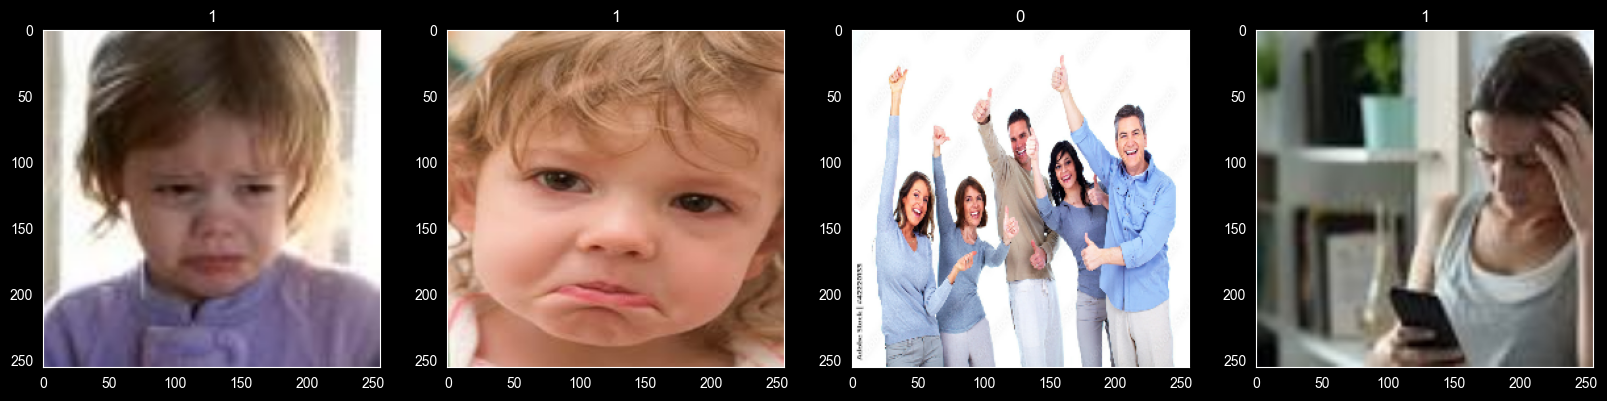

In [52]:
fig, ax=plt.subplots(ncols=4,figsize=(20,20))
for idx, img in enumerate(batch[0][:4]):
    ax[idx].imshow(img.astype(int))
    ax[idx].title.set_text(batch[1][idx])
    ax[idx].grid(False)


In [53]:
# preprocessing
# scale data
data=data.map(lambda x,y:(x/255,y))
data

<_MapDataset element_spec=(TensorSpec(shape=(None, 256, 256, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>

In [62]:
scaled_iterator=data.as_numpy_iterator()
batch=scaled_iterator.next()

In [63]:
batch[0].max()

np.float32(1.0)

In [66]:
len(data)

10

In [64]:
# Split Data
train_size=int(len(data)*0.7)
val_size=int(len(data)*0.2)
test_size=int(len(data)*0.1)

In [67]:
train=data.take(train_size)
val=data.skip(train_size).take(val_size)
test=data.skip(train_size+val_size).take(test_size)

In [70]:
len(train)

7

In [72]:
# Deep Model
# Build Deep learning Model
model=Sequential()
model.add(Conv2D(16,(3,3),1, activation='relu',input_shape=(256,256,3)))
model.add(MaxPooling2D())

model.add(Conv2D(32,(3,3),1, activation='relu'))
model.add(MaxPooling2D())

model.add(Conv2D(16,(3,3),1, activation='relu'))
model.add(MaxPooling2D())

model.add(Flatten())

model.add(Dense(256,activation='relu'))
model.add(Dense(1,activation='sigmoid'))


C:\Users\moham\PycharmProjects\Face_happy_Sad_Classification\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [73]:
model.compile('adam',loss=tf.losses.BinaryCrossentropy(),metrics=['accuracy'])

In [74]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 254, 254, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 127, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 125, 125, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 62, 62, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 60, 60, 16)     │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 30, 30, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 14400)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     3,686,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,696,625 (14.10 MB)

 Trainable params: 3,696,625 (14.10 MB)

 Non-trainable params: 0 (0.00 B)

In [77]:
# train
logdir = 'logs'

tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=logdir)

hist = model.fit(
    train,
    epochs=20,
    validation_data=val,
    callbacks=[tensorboard_callback]
)


Epoch 1/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 224ms/step - accuracy: 0.4866 - loss: 0.7498 - val_accuracy: 0.6250 - val_loss: 0.6787
Epoch 2/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 222ms/step - accuracy: 0.5982 - loss: 0.6546 - val_accuracy: 0.5938 - val_loss: 0.6162
Epoch 3/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 288ms/step - accuracy: 0.7500 - loss: 0.5573 - val_accuracy: 0.7656 - val_loss: 0.4941
Epoch 4/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 418ms/step - accuracy: 0.7143 - loss: 0.5727 - val_accuracy: 0.7031 - val_loss: 0.5303
Epoch 5/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 237ms/step - accuracy: 0.8170 - loss: 0.4811 - val_accuracy: 0.9688 - val_loss: 0.4275
Epoch 6/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 181ms/step - accuracy: 0.8616 - loss: 0.4115 - val_accuracy: 0.9062 - val_loss: 0.2929
Epoch 7/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 195ms/step - accuracy: 0.8393 - loss: 0.3566 - val_accuracy: 0.7188 - val_loss: 0.4817
Epoch 8/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 184ms/step - accuracy: 0.8393 - loss: 0.3258 - val_accuracy: 0.9375 - val_loss:

In [79]:
hist.history

{'accuracy': [0.4866071343421936,
  0.5982142686843872,
  0.75,
  0.7142857313156128,
  0.8169642686843872,
  0.8616071343421936,
  0.8392857313156128,
  0.8392857313156128,
  0.9196428656578064,
  0.8705357313156128,
  0.9285714030265808,
  0.9330357313156128,
  0.9508928656578064,
  0.9821428656578064,
  0.9821428656578064,
  0.9821428656578064,
  0.9821428656578064,
  0.9955357313156128,
  0.9955357313156128,
  1.0],
 'loss': [0.7497792840003967,
  0.6545790433883667,
  0.5573412775993347,
  0.5726843476295471,
  0.4810735881328583,
  0.41147616505622864,
  0.3565852642059326,
  0.32581982016563416,
  0.2504148781299591,
  0.31676557660102844,
  0.2453199177980423,
  0.21676158905029297,
  0.1510835587978363,
  0.07706224918365479,
  0.05474844202399254,
  0.07267214357852936,
  0.048508141189813614,
  0.03394259139895439,
  0.025544660165905952,
  0.013973807916045189],
 'val_accuracy': [0.625,
  0.59375,
  0.765625,
  0.703125,
  0.96875,
  0.90625,
  0.71875,
  0.9375,
  0.78125,

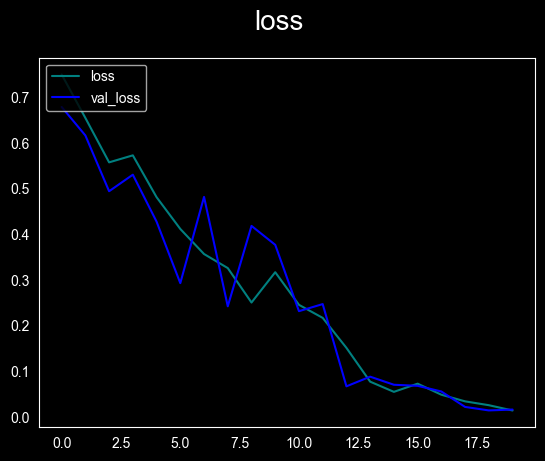

In [81]:
# plot performance
fig=plt.figure()
plt.plot(hist.history['loss'],color='teal',label='loss')
plt.plot(hist.history['val_loss'],color='blue',label='val_loss')
fig.suptitle('loss',fontsize=20)
plt.legend(loc='upper left')
plt.grid(False)
plt.show()

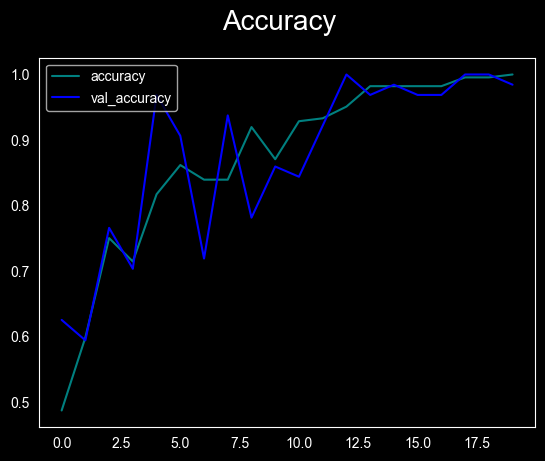

In [82]:
fig=plt.figure()
plt.plot(hist.history['accuracy'],color='teal',label='accuracy')
plt.plot(hist.history['val_accuracy'],color='blue',label='val_accuracy')
fig.suptitle('Accuracy',fontsize=20)
plt.legend(loc='upper left')
plt.grid(False)
plt.show()

In [84]:
# Evaluation
pre=Precision()
re=Recall()
acc=BinaryAccuracy()


In [85]:
for batch in test.as_numpy_iterator():
    X,y=batch
    yhat=model.predict(X)
    pre.update_state(y,yhat)
    re.update_state(y,yhat)
    acc.update_state(y,yhat)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step


In [88]:
print(f'Precision: {pre.result().numpy()},recall: {re.result().numpy()},Binary Accuracy {acc.result().numpy()}')

Precision: 1.0,recall: 1.0,Binary Accuracy 1.0


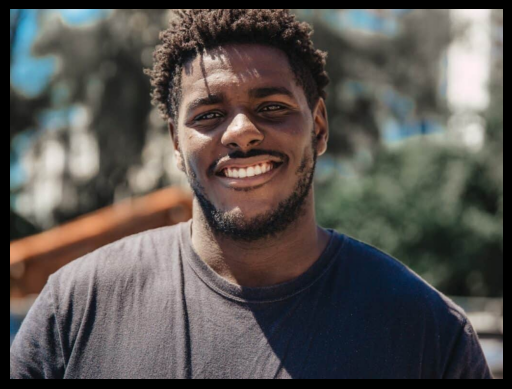

In [96]:
img = cv2.imread('data\happy\happy-people-1024x768.jpeg')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img)
plt.axis('off')
plt.show()

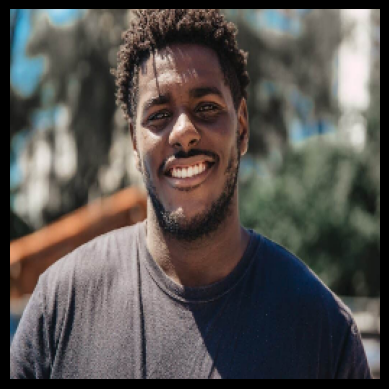

In [98]:
resize=tf.image.resize(img,(256,256))
plt.imshow(resize.numpy().astype(int))
plt.axis('off')
plt.show()

In [99]:
yhat=model.predict(np.expand_dims(resize/255,0))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step


In [100]:
yhat

array([[0.03939703]], dtype=float32)

In [101]:
if yhat>0.5:
    print('predict it was the sad image')
else:
    print('predict it was the happy image')

predict it was the happy image


In [103]:
#save model
model.save(os.path.join('models','HappySadModel.h5'))